In [1]:
from experiments.dj.likelihood_tables import LikelihoodConfig
from experiments.dj.result_tables import (
    AdaptPriorResult,
    FlowPriorResult,
    LikelihoodResult,
)
from experiments.dj.prior_tables import FlowPriorConfig
from experiments.dj.trainer_tables import FPTrainerConfig, LLTrainerConfig
from experiments.dj.dataloader_tables import DataLoaderConfig
from experiments.dj.dj_helpers import fetch_best_model_results
import gensn.distributions as G
import torch
from task_transfer.ml_lib.data_loading import build_dataloaders
from task_transfer.evaluation.evaluate_generative_model import (
    evaluate_flow_prior,
    compute_logl,
    adapt_prior_eval_criterion,
    compute_joint_logl,
    logl_mc_marginal_eval,
)

[2024-07-11 05:44:40,887][INFO]: Connecting sshrinivasan@134.76.19.44:3306
[2024-07-11 05:44:42,127][INFO]: Connected sshrinivasan@134.76.19.44:3306


In [2]:
download_path = "/tmp"
criterion = "val_ll_mean"
k = 1

prior_config_proj_col = "fp_id"
best_val_prior_results = fetch_best_model_results(
    result_table=FlowPriorResult,
    config_table=FlowPriorConfig,
    data_loader_config_table=DataLoaderConfig,
    trainer_config_table=FPTrainerConfig,
    config_proj_col=prior_config_proj_col,
    criterion=criterion,
    k=k,
    download_path=download_path,
)
pre_task_trained_prior = torch.load(best_val_prior_results["model"], map_location="cpu")

In [3]:
dataloader_args = {
    "data_fname": "/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_1_dataset.pkl",
    "train_prop": 0.7,
    "val_prop": 0.2,
}
train_loader, val_loader, test_loader = build_dataloaders(
    data_fname=dataloader_args["data_fname"],
    train_prop=dataloader_args["train_prop"],
    val_prop=dataloader_args["val_prop"],
    batch_size=128,
)

In [4]:
# get likelihood model for marginal likelihood
likelihood_config_proj_col = "ll_id"
best_val_likelihood_results = fetch_best_model_results(
    result_table=LikelihoodResult,
    config_table=LikelihoodConfig,
    data_loader_config_table=DataLoaderConfig,
    trainer_config_table=LLTrainerConfig,
    config_proj_col=likelihood_config_proj_col,
    criterion=criterion,
    k=k,
    download_path=download_path,
)
likelihood_model = torch.load(best_val_likelihood_results["model"], map_location="cpu")

In [5]:
pre_task_trained_joint = G.Joint(
    prior=pre_task_trained_prior, conditional=likelihood_model
)

In [6]:
import wandb
wandb.init(project="random", entity="walkerlab")

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


In [7]:
data_dim = 1
cond_dim = 0
mc_sample_size=(50_000),
device="cpu"
reduction="none"
uncertainty="sem"
normalize="none"
unit="nats"
logl_mc_marg_pre_task_train, _ = logl_mc_marginal_eval(
    joint_model=pre_task_trained_joint,
    data_loader=train_loader,
    data_dim=data_dim,
    mc_sample_size=mc_sample_size,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
logl_mc_marg_pre_task_val, _ = logl_mc_marginal_eval(
    joint_model=pre_task_trained_joint,
    data_loader=val_loader,
    data_dim=data_dim,
    mc_sample_size=mc_sample_size,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
logl_mc_marg_pre_task_test, _ = logl_mc_marginal_eval(
    joint_model=pre_task_trained_joint,
    data_loader=test_loader,
    data_dim=data_dim,
    mc_sample_size=mc_sample_size,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

In [8]:
import numpy as np

def compute_logl_data_marginal(
    conditional_model, 
    data_loader, 
    data_dim,
    cond_dim,
    device="cpu",
    reduction="mean",
    uncertainty="sem",
    normalize="none",
    unit="nats",
):
    log_probs = []
    for batch in data_loader:
        data = batch[data_dim].to(device)
        cond = batch[cond_dim].to(device)
        conditional_ll = conditional_model(data, cond=cond.unsqueeze(1))
        marginal_ll = torch.logsumexp(conditional_ll, dim=0) - torch.log(
            torch.tensor(conditional_ll.shape[0])
        )
        log_probs.append(marginal_ll)
        if reduction == "mean":
            lp = torch.cat(log_probs).mean().item()
        elif reduction == "sum":
            lp = torch.cat(log_probs).sum().item()
        elif reduction == "none":
            lp = torch.cat(log_probs)
        else:
            raise ValueError("Unknown reduction")
        if uncertainty == "sem":
            lp_uncertainty = torch.cat(log_probs).std() / (len(log_probs) ** 0.5)
            lp_uncertainty = lp_uncertainty.item()
        elif uncertainty == "std":
            lp_uncertainty = torch.cat(log_probs).std()
            lp_uncertainty = lp_uncertainty.item()
        elif uncertainty == "none":
            lp_uncertainty = None
        else:
            raise ValueError("Unknown uncertainty measure")
        if normalize == "per_dim":
            batch = next(iter(data_loader))
            data = batch[data_dim]
            lp /= data.shape[1:].numel()
        elif normalize == "none":
            pass
        if unit == "nats":
            pass
        elif unit == "bits":
            lp /= np.log(2)
        else:
            raise ValueError("Unknown unit")
    return lp, lp_uncertainty

In [9]:
logl_data_marg_train, _ = compute_logl_data_marginal(
    conditional_model=likelihood_model,
    data_loader=train_loader,
    data_dim=data_dim,
    cond_dim=cond_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
logl_data_marg_val, _ = compute_logl_data_marginal(
    conditional_model=likelihood_model,
    data_loader=val_loader,
    data_dim=data_dim,
    cond_dim=cond_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
logl_data_marg_test, _ = compute_logl_data_marginal(
    conditional_model=likelihood_model,
    data_loader=test_loader,
    data_dim=data_dim,
    cond_dim=cond_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

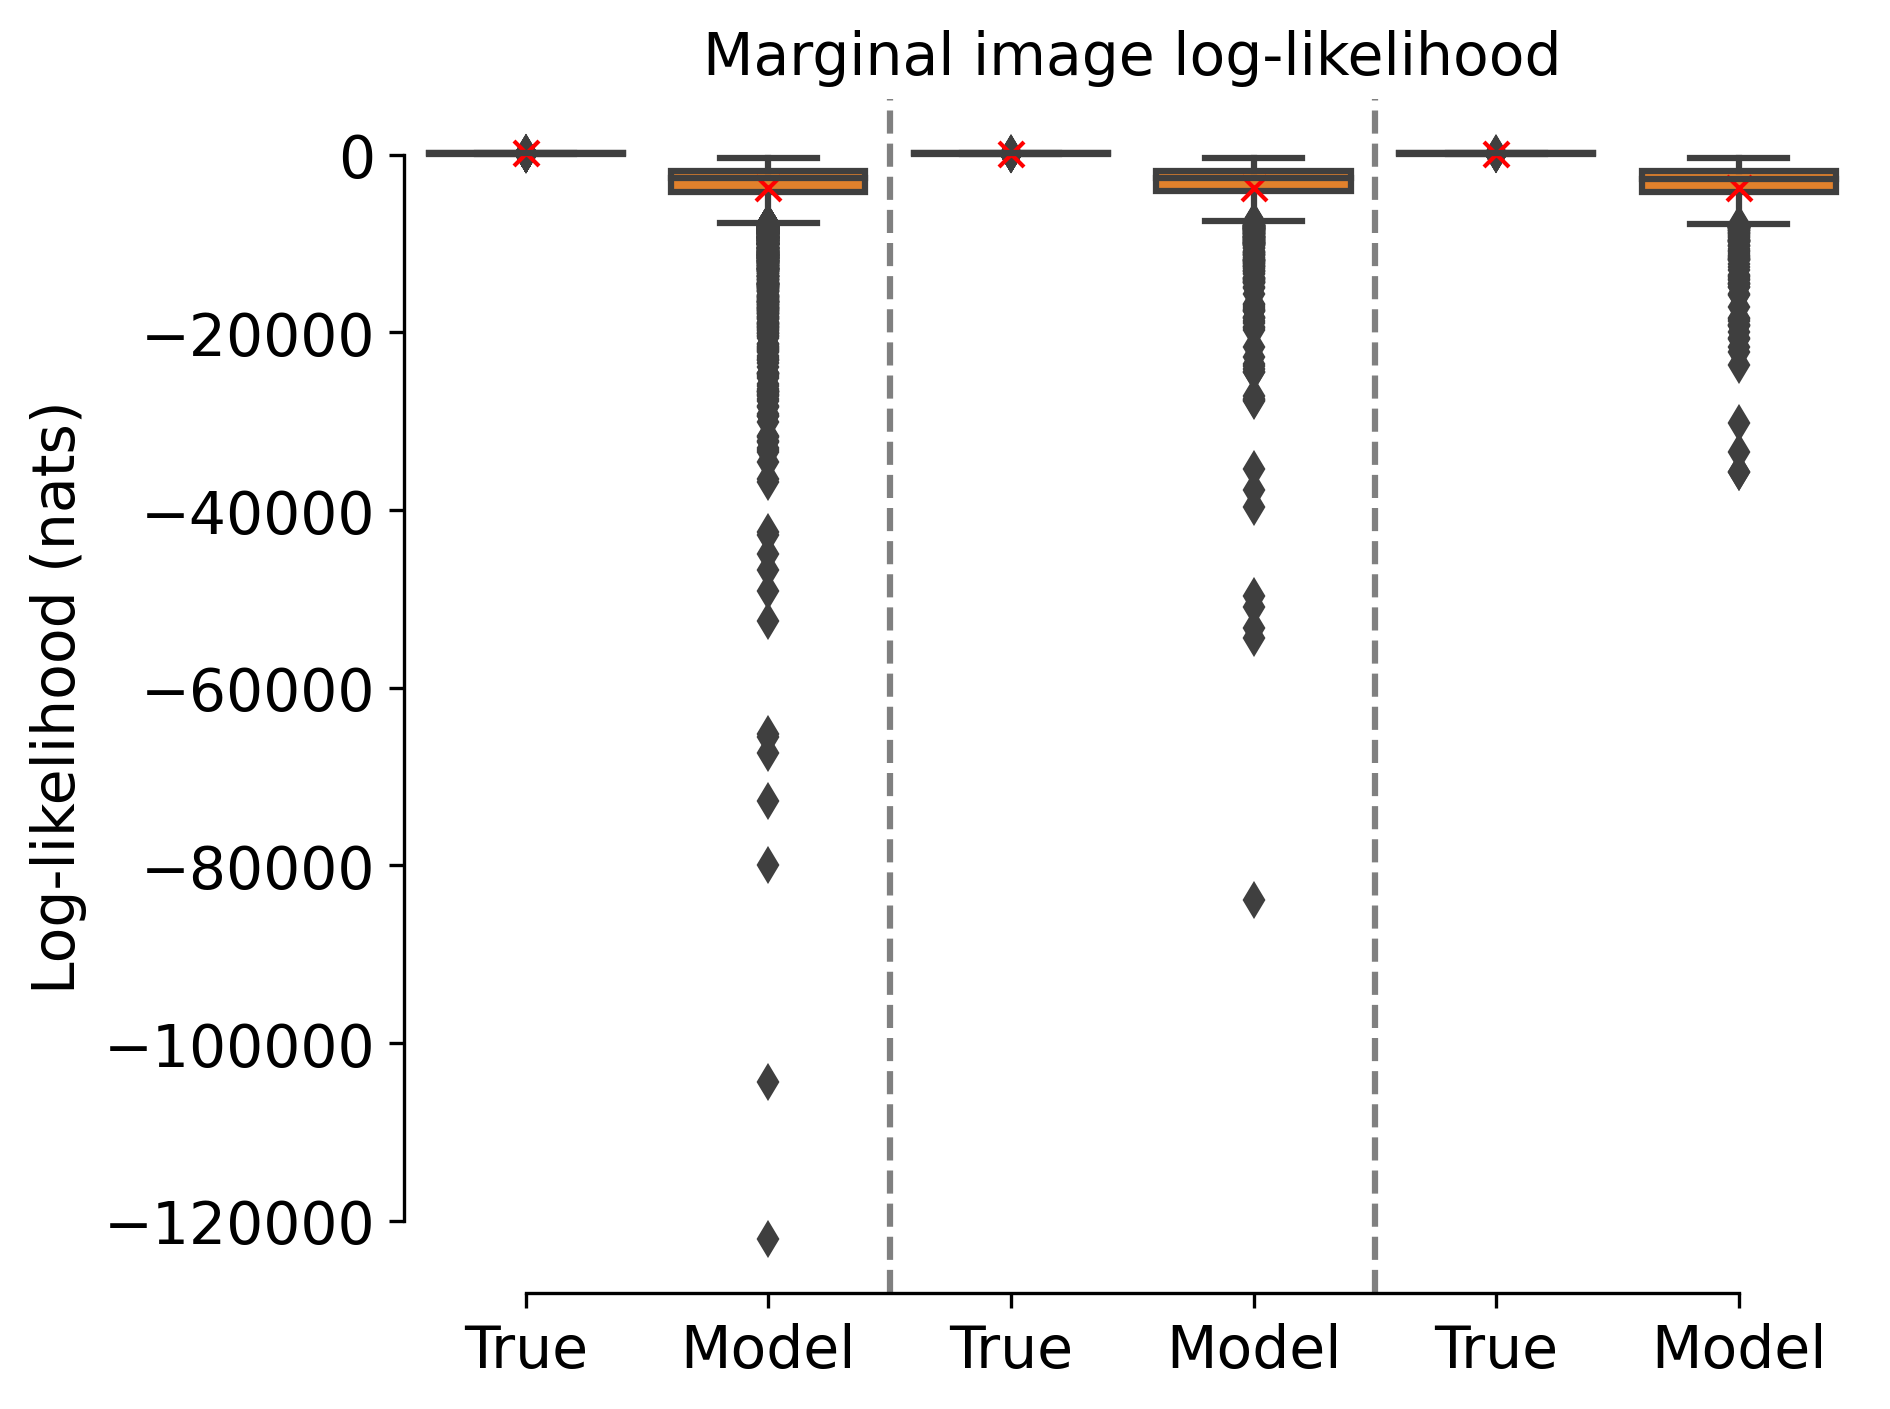

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

data = [
    logl_data_marg_train.detach(),
    logl_mc_marg_pre_task_train.detach(),
    logl_data_marg_val.detach(),
    logl_mc_marg_pre_task_val.detach(),
    logl_data_marg_test.detach(),
    logl_mc_marg_pre_task_test.detach(),
]
labels = [
    "True",
    "Model",
    "True",
    "Model",
    "True",
    "Model",
]
# Creating a boxplot
fig, ax = plt.subplots(dpi=300)
# set two colors as palette and cycle
palette = sns.color_palette("tab10", n_colors=2)
ax = sns.boxplot(data=data, ax=ax, palette=palette)
# add mean values
for i, value in enumerate(data):
    # ax.text(i + 0.3, value.mean() + 0.5, f"{value.mean():.2f}", ha="center", va="bottom", fontsize=8)
    # add a red dot
    ax.plot(i, value.mean(), "rx")
ax.set_xticklabels(labels)
ax.set_title("Marginal image log-likelihood", fontsize=14)
ax.set_ylabel("Log-likelihood (nats)", fontsize=14)
ax.tick_params(axis="both", which="major", labelsize=14)
for tick in range(len(labels)):
    if tick % 2 == 0 and tick != 0:
        ax.axvline(tick - 0.5, ls="--", color="grey")
# ax.set_yticks(range(-100, 0, 10))
sns.despine(ax=ax, trim=True)
plt.tight_layout()

# # Display the plot
# plt.show()

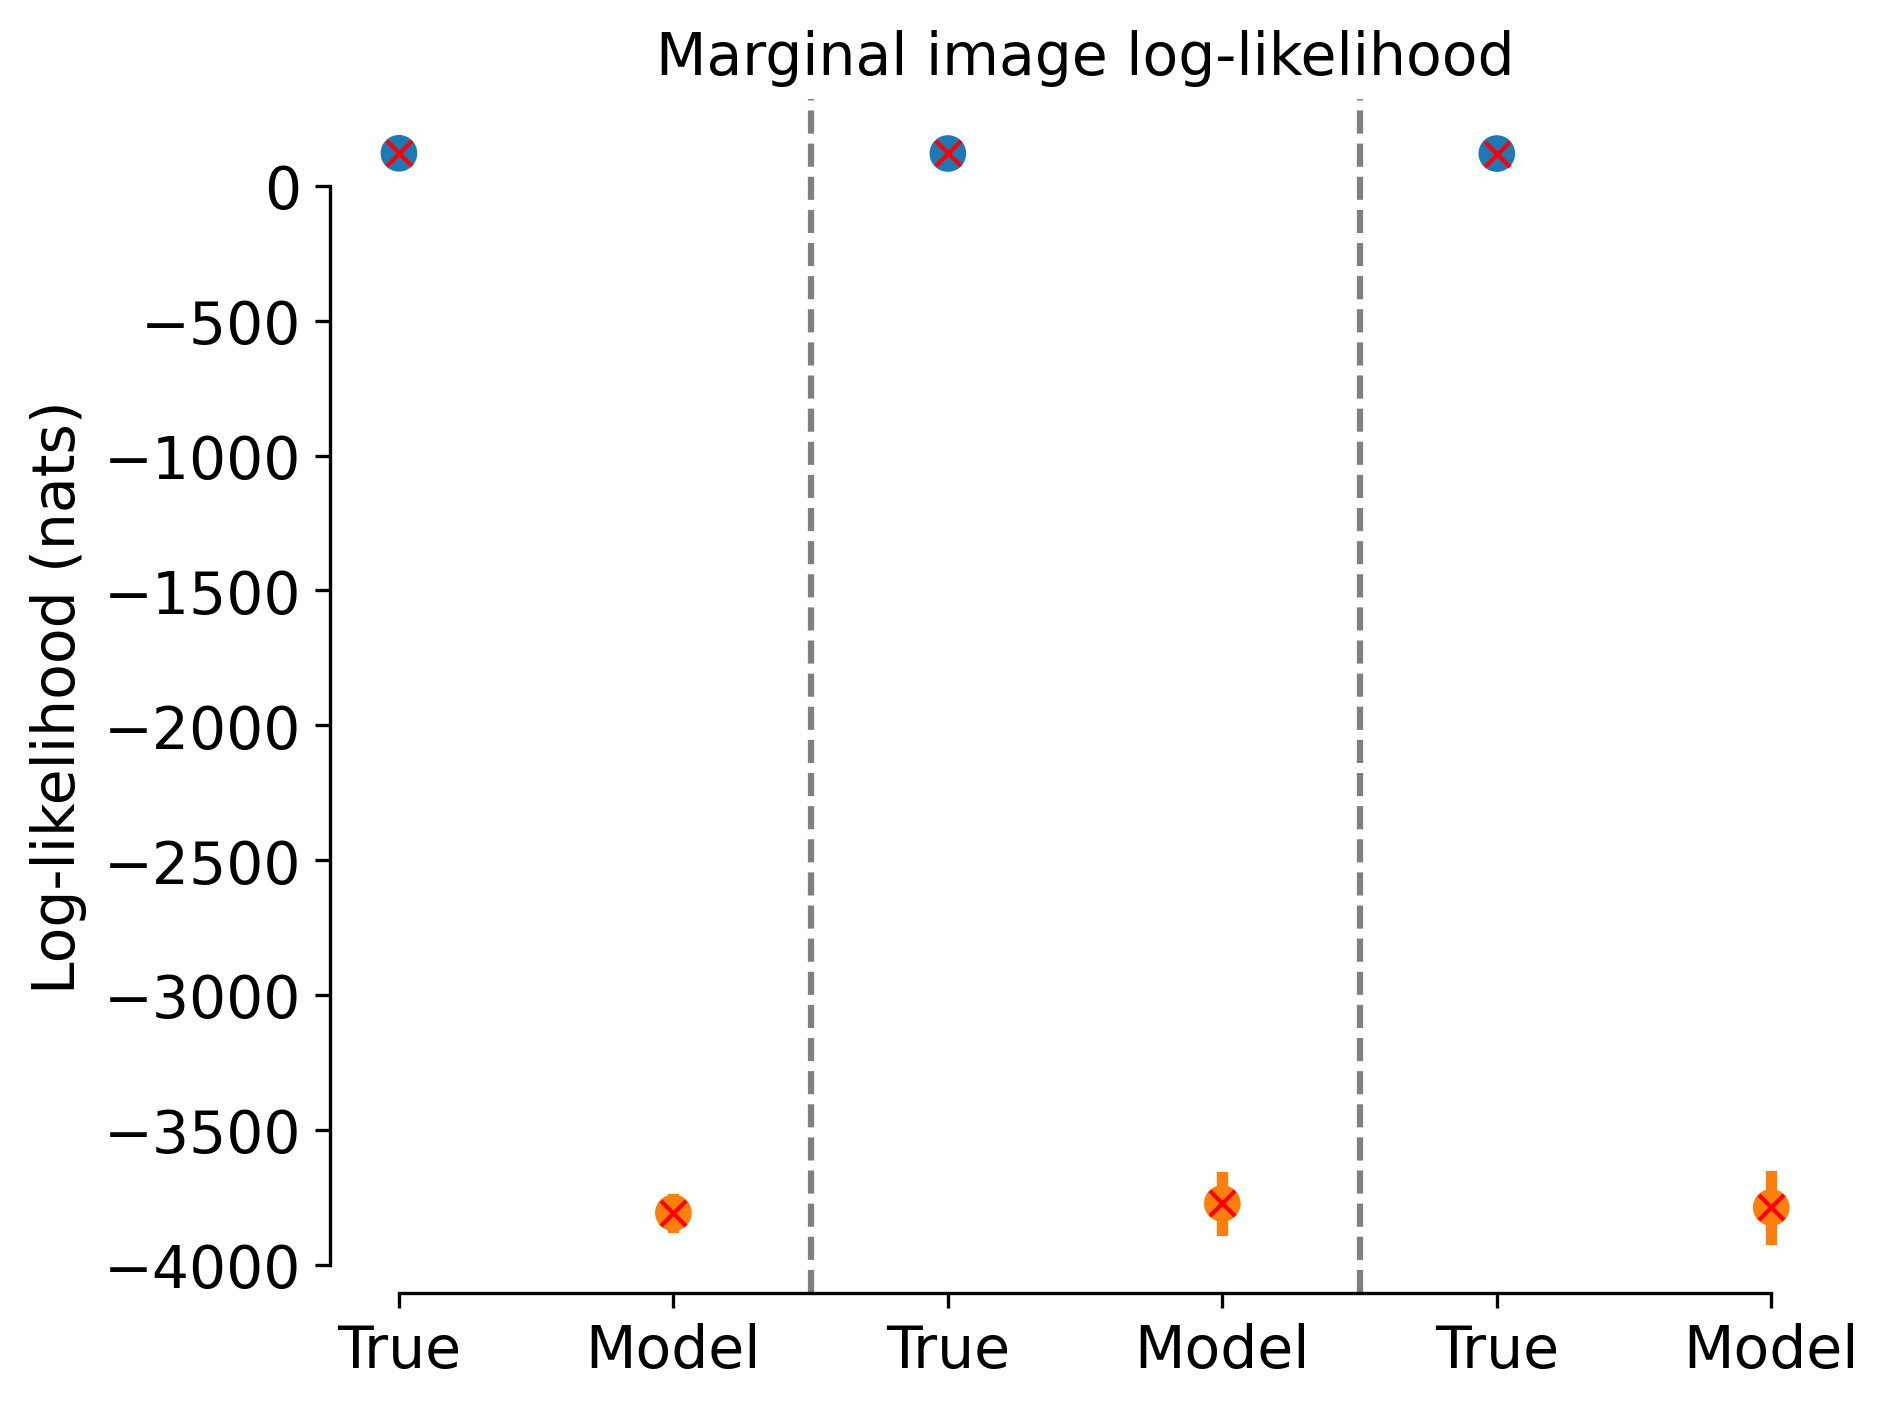

In [11]:
data = [
    logl_data_marg_train.detach(),
    logl_mc_marg_pre_task_train.detach(),
    logl_data_marg_val.detach(),
    logl_mc_marg_pre_task_val.detach(),
    logl_data_marg_test.detach(),
    logl_mc_marg_pre_task_test.detach(),
]
labels = [
    "True",
    "Model",
    "True",
    "Model",
    "True",
    "Model",
]
# Creating a boxplot
fig, ax = plt.subplots(dpi=300)
# set two colors as palette and cycle
palette = sns.color_palette("tab10", n_colors=2)
ax = sns.pointplot(data=data, ax=ax, palette=palette, errorbar="se")
# add mean values
for i, value in enumerate(data):
    # ax.text(i + 0.3, value.mean() + 0.5, f"{value.mean():.2f}", ha="center", va="bottom", fontsize=8)
    # add a red dot
    ax.plot(i, value.mean(), "rx")
ax.set_xticklabels(labels)
ax.set_title("Marginal image log-likelihood", fontsize=14)
ax.set_ylabel("Log-likelihood (nats)", fontsize=14)
ax.tick_params(axis="both", which="major", labelsize=14)
for tick in range(len(labels)):
    if tick % 2 == 0 and tick != 0:
        ax.axvline(tick - 0.5, ls="--", color="grey")
# ax.set_yticks(range(-100, 0, 10))
sns.despine(ax=ax, trim=True)
plt.tight_layout()

# # Display the plot
# plt.show()